In [2]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
import pandas as pd
import hashlib

def keep_session(session_id, p=0.10):
    # Agar kisi wajah se session_id missing hai, toh usko turant reject kar do
    if pd.isna(session_id): 
        return False
    # Hashing se pehle explicitly str() lagaya hai taaki string/float conflict na aaye
    return int(hashlib.md5(str(session_id).encode('utf-8')).hexdigest(), 16) % 100 < (p * 100)

chunks = []

# Chunksize ke through 10 Lakh rows load kar rahe hain
for chunk in pd.read_csv("2019-Nov.csv", chunksize=1000000):
    
    # 1. DATA CLEANING: Wo 1 missing user_session wali row yahan turant drop ho jayegi
    chunk = chunk.dropna(subset=['user_session'])
    
    # Note: Hum 'brand' aur 'category_code' ke missing values ko drop NAHI kar rahe,
    # kyunki user ne agar unbranded item view kiya hai, toh bhi wo ML/GRU ke liye ek important action hai.
    
    # 2. FILTERING: Sirf 10% users ke sessions ko rakho
    filtered_chunk = chunk[chunk['user_session'].apply(keep_session)]
    
    chunks.append(filtered_chunk)

# Saare clean aur filtered chunks ko ek final DataFrame mein combine kar lo
final_df = pd.concat(chunks, ignore_index=True)

# Verification ke liye print kar sakte hain
print("Final Data Shape:", final_df.shape)

In [3]:
final_df=pd.read_csv('Filtered_dataset.csv')

In [4]:
final_df.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:01 UTC,view,1306421,2053013558920217191,computers.notebook,hp,514.56,514028527,df8184cc-3694-4549-8c8c-6b5171877376
1,2019-11-01 00:00:03 UTC,view,16700260,2053013559901684381,furniture.kitchen.chair,NaN,31.64,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
2,2019-11-01 00:00:08 UTC,view,1307115,2053013558920217191,computers.notebook,hp,411.59,514028527,df8184cc-3694-4549-8c8c-6b5171877376
3,2019-11-01 00:00:08 UTC,view,1004708,2053013555631882655,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843
4,2019-11-01 00:00:12 UTC,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
5,2019-11-01 00:00:12 UTC,view,10800182,2053013554994348409,NaN,redmond,61.10,527322328,5054190a-46cb-4211-a8f1-16fc1a060ed8
6,2019-11-01 00:00:13 UTC,view,15200565,2053013553484398879,NaN,hyper,54.06,518758107,f617be3c-8447-4aaf-b9b7-2e23a21a8b58
7,2019-11-01 00:00:17 UTC,view,1800729,2053013554415534427,electronics.video.tv,samsung,289.33,515782589,f2081cf0-0ee3-4bf1-9b40-e5e580f9ace3
8,2019-11-01 00:00:18 UTC,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
9,2019-11-01 00:00:18 UTC,view,10701060,2053013561277416167,NaN,NaN,66.90,512996121,23375068-25db-44fd-86a8-52123e47e93e


In [5]:
final_df.duplicated().sum()

np.int64(10434)

In [6]:
Percentage_duplicated=(10434/(final_df.shape[0]))*100
print(Percentage_duplicated)

0.1548557151094149


In [7]:
final_df = final_df.drop_duplicates()

In [8]:
final_df.isnull().sum()

event_time             0
event_type             0
product_id             0
category_id            0
category_code    2184325
brand             922756
price                  0
user_id                0
user_session           0
dtype: int64

Percentage_of_missing_values

In [9]:
(final_df.isnull().sum()/final_df.shape[0])*100

event_time        0.000000
event_type        0.000000
product_id        0.000000
category_id       0.000000
category_code    32.468836
brand            13.716280
price             0.000000
user_id           0.000000
user_session      0.000000
dtype: float64

In [10]:
final_df['event_time'] = pd.to_datetime(final_df['event_time'])

In [ ]:
final_df.info()

<class 'pandas.DataFrame'>
Index: 6727451 entries, 0 to 6737884
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 513.3 MB


In [12]:
final_df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-11-01 00:00:01 UTC,view,1306421,2053013558920217191,computers.notebook,hp,514.56,514028527,df8184cc-3694-4549-8c8c-6b5171877376
1,2019-11-01 00:00:03 UTC,view,16700260,2053013559901684381,furniture.kitchen.chair,NaN,31.64,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f
2,2019-11-01 00:00:08 UTC,view,1307115,2053013558920217191,computers.notebook,hp,411.59,514028527,df8184cc-3694-4549-8c8c-6b5171877376
3,2019-11-01 00:00:08 UTC,view,1004708,2053013555631882655,electronics.smartphone,huawei,151.99,566143627,aa610ab3-5c60-4551-8a2b-8c999dddf843
4,2019-11-01 00:00:12 UTC,view,16700826,2053013559901684381,furniture.kitchen.chair,nika,47.77,566255262,173d7b72-1db7-4638-8207-be8148bf3c9f


In [11]:
# Data ko pehle User Session se group karo, aur fir us session ke andar Time ke hisaab se sort karo
final_df = final_df.sort_values(by=['user_session', 'event_time']).reset_index(drop=True)

In [14]:
!uv pip install missingno

Resolved 16 packages in 654ms
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 86ms
 + missingno==0.5.2


MISSING_NO ANALYSIS:-

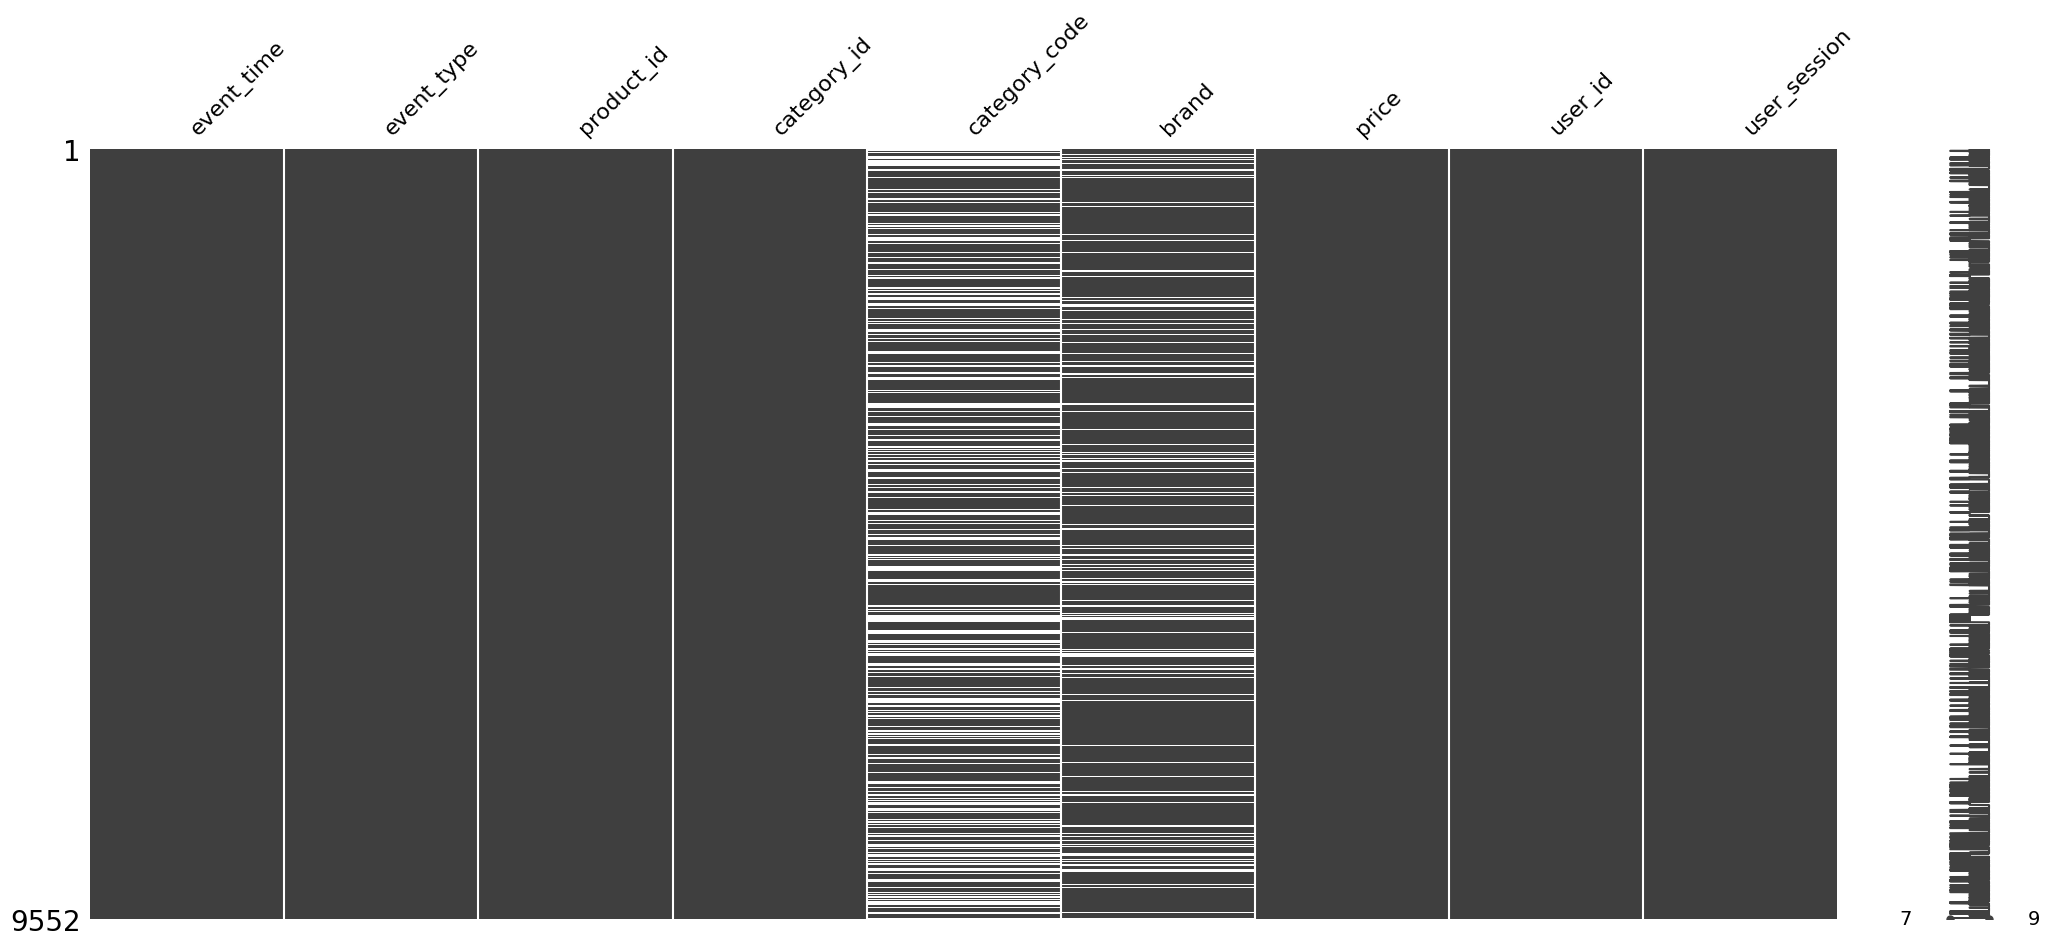

In [16]:
import missingno as msno
# 1. Pehle 1000 random aur unique 'user_session' IDs uthao
random_session_ids = pd.Series(final_df['user_session'].dropna().unique()).sample(2000, random_state=42)

# 2. Ab original dataframe se sirf un 1000 sessions ka PURA data filter kar lo
sample_df = final_df[final_df['user_session'].isin(random_session_ids)]

# 3. Ab plot karo (Ye perfect insights dega!)
msno.matrix(sample_df)
plt.show()

<Figure size 0.5x0.5 with 0 Axes>

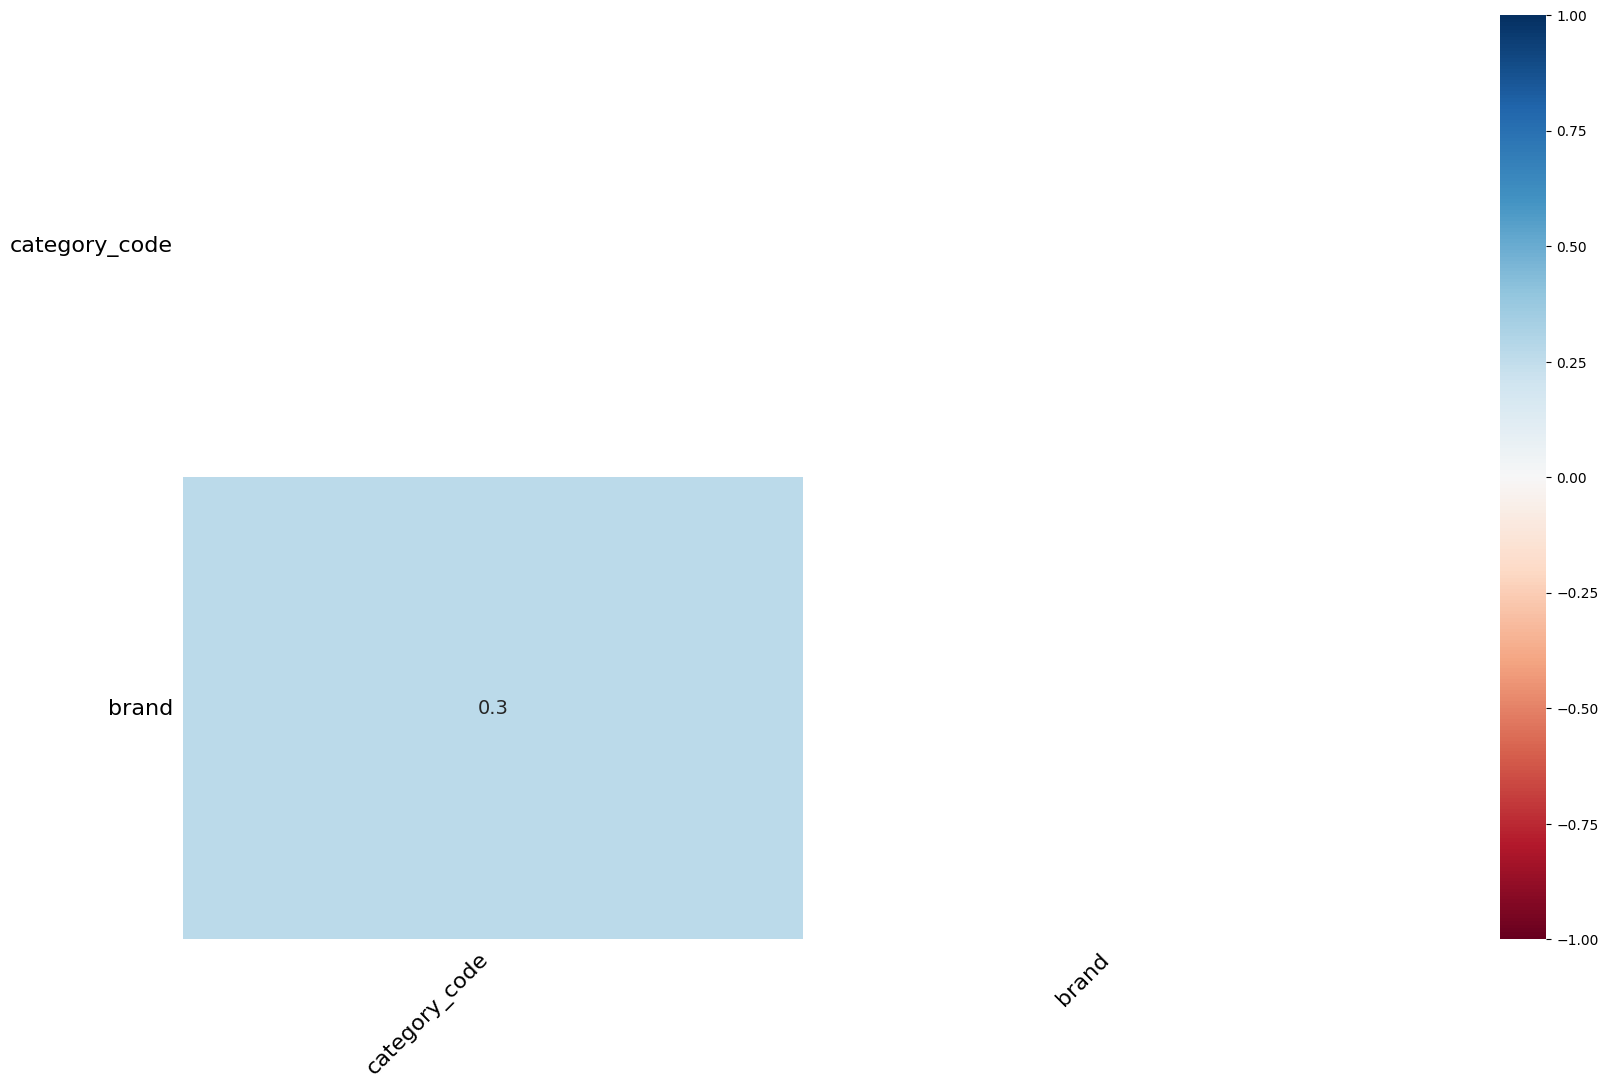

In [19]:
plt.figure(figsize=(.005,.005))
msno.heatmap(sample_df)
plt.show()

EK hypothesis lii h jisme hum kehte h ki har category id ke liye different category code h!

In [20]:
# STEP 1: Rule book (Dictionary) banate hain
category_map = final_df.dropna(subset=['category_code']).set_index('category_id')['category_code'].to_dict()

# STEP 2: NAYA COLUMN banate hain aur original ko waise hi chhod dete hain
final_df['category_code_filled'] = final_df['category_code']

# STEP 3: Sirf is NAYE COLUMN ki missing values ko apni dictionary se fill karte hain
final_df['category_code_filled'] = final_df['category_code_filled'].fillna(final_df['category_id'].map(category_map))

# STEP 4: Jo bilkul anjaan hain, unhe tag de dete hain
final_df['category_code_filled'] = final_df['category_code_filled'].fillna('unknown_category')

In [24]:
# STEP 1: Total khali (null) rows ginna
original_missing = final_df['category_code'].isnull().sum()

# STEP 2: Ek mask banana jo un rows ko pakdega jo pehle NaN thi, 
# PAR ab unhe dictionary se ek valid naam mil gaya hai (yani wo 'unknown_category' nahi hain)
recovered_mask = final_df['category_code'].isnull() & (final_df['category_code_filled'] != 'unknown_category')

# Successfully recover hui rows ko ginna
recovered_count = recovered_mask.sum()

# STEP 3: The Result Summary
print("-" * 50)
print("🔍 RECOVERY PROOF REPORT")
print("-" * 50)
print(f"1. Total Original Missing Values: {original_missing}")
print(f"2. Successfully Recovered by ID:  {recovered_count}")
print(f"3. Still Unknown (No Match): {original_missing - recovered_count}")
print("-" * 50)

--------------------------------------------------
🔍 RECOVERY PROOF REPORT
--------------------------------------------------
1. Total Original Missing Values: 2184325
2. Successfully Recovered by ID:  0
3. Still Unknown (No Match): 2184325
--------------------------------------------------


The Above Clearly gives proof that there is no actually benifit from it.Thus,Our Hypo. is wrong

In [ ]:
# STEP 1: Product_ID se Category aur Brand ki perfect dictionaries banate hain
prod_cat_dict = final_df.dropna(subset=['category_code']).drop_duplicates('product_id').set_index('product_id')['category_code'].to_dict()
prod_brand_dict = final_df.dropna(subset=['brand']).drop_duplicates('product_id').set_index('product_id')['brand'].to_dict()

# STEP 2: NAYE COLUMNS banate hain aur unme mapped values fill karte hain
# (Original columns ko touch nahi kar rahe)
final_df['category_code_filled'] = final_df['category_code'].fillna(final_df['product_id'].map(prod_cat_dict))
final_df['brand_filled'] = final_df['brand'].fillna(final_df['product_id'].map(prod_brand_dict))

# STEP 3: Jo products sach mein anjaan hain, unko NAYE COLUMNS mein dummy tags dekar close karte hain
final_df['category_code_filled'] = final_df['category_code_filled'].fillna('unknown_category')
final_df['brand_filled'] = final_df['brand_filled'].fillna('unbranded')

# STEP 4: Final verification (Aamne-saamne compare karne ke liye)
print("Missing values comparison:\n")
print(final_df[['category_code', 'category_code_filled', 'brand', 'brand_filled']].isnull().sum())

Checking ki har Product_id is unique for Cateory_code

In [25]:
# STEP 1: Pehle wo data nikalte hain jahan category_code missing nahi hai
valid_cats_df = final_df.dropna(subset=['category_code'])

# STEP 2: Har product_id ke liye check karte hain ki uske paas kitne UNIQUE category codes hain
category_counts = valid_cats_df.groupby('product_id')['category_code'].nunique()

# STEP 3: Aise products filter karte hain jinki 1 se zyada categories hain (Inconsistent data)
inconsistent_products = category_counts[category_counts > 1]

# STEP 4: Result print karte hain
print(f"Total Unique Products: {len(category_counts)}")
print(f"Products with MULTIPLE categories: {len(inconsistent_products)}")

# Agar koi inconsistent product milta hai, toh uska data dekhte hain
if len(inconsistent_products) > 0:
    print("\nKuch inconsistent products ke IDs:")
    print(inconsistent_products.head())

Total Unique Products: 64889
Products with MULTIPLE categories: 0


In [26]:
category_counts

product_id
1000978      1
1001588      1
1001606      1
1001618      1
1001619      1
            ..
100028003    1
100028295    1
100028391    1
100028398    1
100028495    1
Name: category_code, Length: 64889, dtype: int64

Hypothesis Check that can be fill brand and Category_code with Prodcut id:-

In [28]:
# STEP 1: Product_ID se Category aur Brand ki perfect dictionaries banate hain
prod_cat_dict = final_df.dropna(subset=['category_code']).drop_duplicates('product_id').set_index('product_id')['category_code'].to_dict()
prod_brand_dict = final_df.dropna(subset=['brand']).drop_duplicates('product_id').set_index('product_id')['brand'].to_dict()

# STEP 2: NAYE COLUMNS banate hain aur unme mapped values fill karte hain
# (Original columns ko touch nahi kar rahe)
final_df['category_code_filled'] = final_df['category_code'].fillna(final_df['product_id'].map(prod_cat_dict))
final_df['brand_filled'] = final_df['brand'].fillna(final_df['product_id'].map(prod_brand_dict))

In [ ]:
# STEP 1: The Numbers (Kitna data recover hua?)
print("-" * 50)
print("📊 RECOVERY REPORT: CATEGORY & BRAND")
print("-" * 50)

# Category ke stats nikalna
cat_missing_before = final_df['category_code'].isnull().sum()
cat_missing_after = final_df['category_code_filled'].isnull().sum()
cat_recovered = cat_missing_before - cat_missing_after

print(f"🔹 CATEGORY CODE:")
print(f"   Original Missing: {cat_missing_before}")
print(f"   Missing After Fill: {cat_missing_after}")
print(f"   Successfully Recovered: {cat_recovered} rows! 🎉\n")

# Brand ke stats nikalna
brand_missing_before = final_df['brand'].isnull().sum()
brand_missing_after = final_df['brand_filled'].isnull().sum()
brand_recovered = brand_missing_before - brand_missing_after

print(f"🔹 BRAND:")
print(f"   Original Missing: {brand_missing_before}")
print(f"   Missing After Fill: {brand_missing_after}")
print(f"   Successfully Recovered: {brand_recovered} rows! ")
print("-" * 50)

# STEP 2: The Visual Proof (Side-by-Side Comparison)
# Filter lagate hain un rows par jo pehle khali thi, par ab bhar chuki hain
proof_mask_cat = final_df['category_code'].isnull() & final_df['category_code_filled'].notnull()
proof_mask_brand = final_df['brand'].isnull() & final_df['brand_filled'].notnull()

# Category ka proof dikhana (Agar recovery hui hai)
if cat_recovered > 0:
    print("\n👀 PROOF: Category Recovery Example (Before vs After)")
    # Koi bhi random 5 rows utha kar dekhna
    display(final_df[proof_mask_cat][['product_id', 'category_code', 'category_code_filled']].sample(5))

# Brand ka proof dikhana (Agar recovery hui hai)
if brand_recovered > 0:
    print("\n👀 PROOF: Brand Recovery Example (Before vs After)")
    display(final_df[proof_mask_brand][['product_id', 'brand', 'brand_filled']].sample(5))

--------------------------------------------------
📊 RECOVERY REPORT: CATEGORY & BRAND
--------------------------------------------------
🔹 CATEGORY CODE:
   Original Missing: 2184325
   Missing After Fill: 2184325
   Successfully Recovered: 0 rows! 🎉

🔹 BRAND:
   Original Missing: 922756
   Missing After Fill: 891355
   Successfully Recovered: 31401 rows! 🎉
--------------------------------------------------

👀 PROOF: Brand Recovery Example (Before vs After)


,product_id,brand,brand_filled
5062685,100009754,NaN,xiaomi
4811958,14702052,NaN,satura
3697409,1005284,NaN,samsung
3761321,26800076,NaN,startline
465105,100006078,NaN,bq


# GRAPHS:-

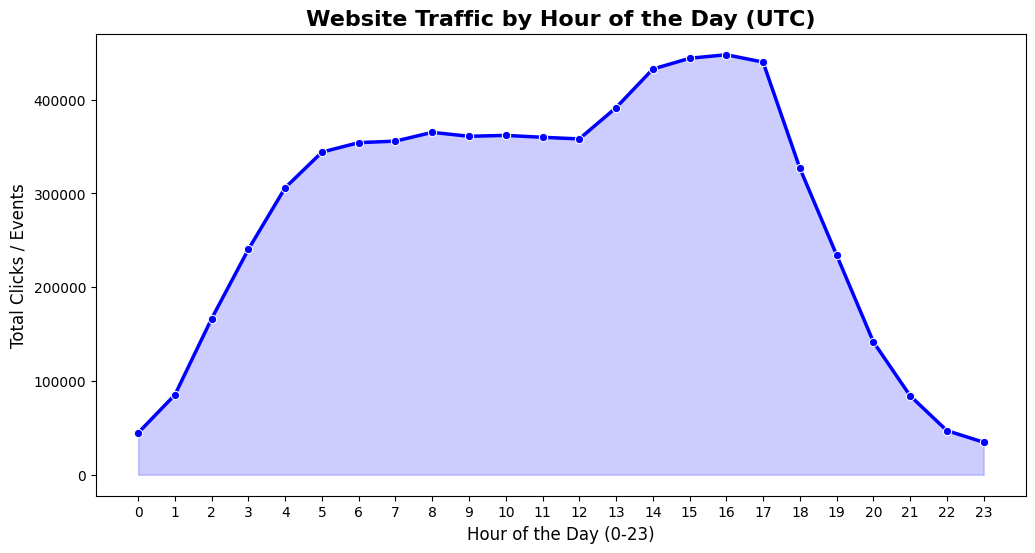

In [30]:
plt.figure(figsize=(12, 6))

# event_time se hour extract kar rahe hain
final_df['hour'] = final_df['event_time'].dt.hour
hourly_traffic = final_df['hour'].value_counts().sort_index().reset_index()
hourly_traffic.columns = ['Hour', 'Traffic_Count']

sns.lineplot(x='Hour', y='Traffic_Count', data=hourly_traffic, marker='o', color='b', linewidth=2.5)
plt.title('Website Traffic by Hour of the Day (UTC)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of the Day (0-23)', fontsize=12)
plt.ylabel('Total Clicks / Events', fontsize=12)
plt.xticks(range(0, 24)) # X-axis par saare ghante dikhane ke liye
plt.fill_between(hourly_traffic['Hour'], hourly_traffic['Traffic_Count'], alpha=0.2, color='b')

plt.show()

In [31]:
hourly_traffic

,Hour,Traffic_Count
0,0,44647
1,1,85246
2,2,166584
3,3,240484
4,4,306058
5,5,344029
6,6,354125
7,7,355744
8,8,365111
9,9,360892


C:\Users\asus\AppData\Local\Temp\ipykernel_20100\2362239005.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_viewed.values, y=top_viewed.index, ax=axes[0], palette='Blues_r')
C:\Users\asus\AppData\Local\Temp\ipykernel_20100\2362239005.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[1], palette='Greens_r')


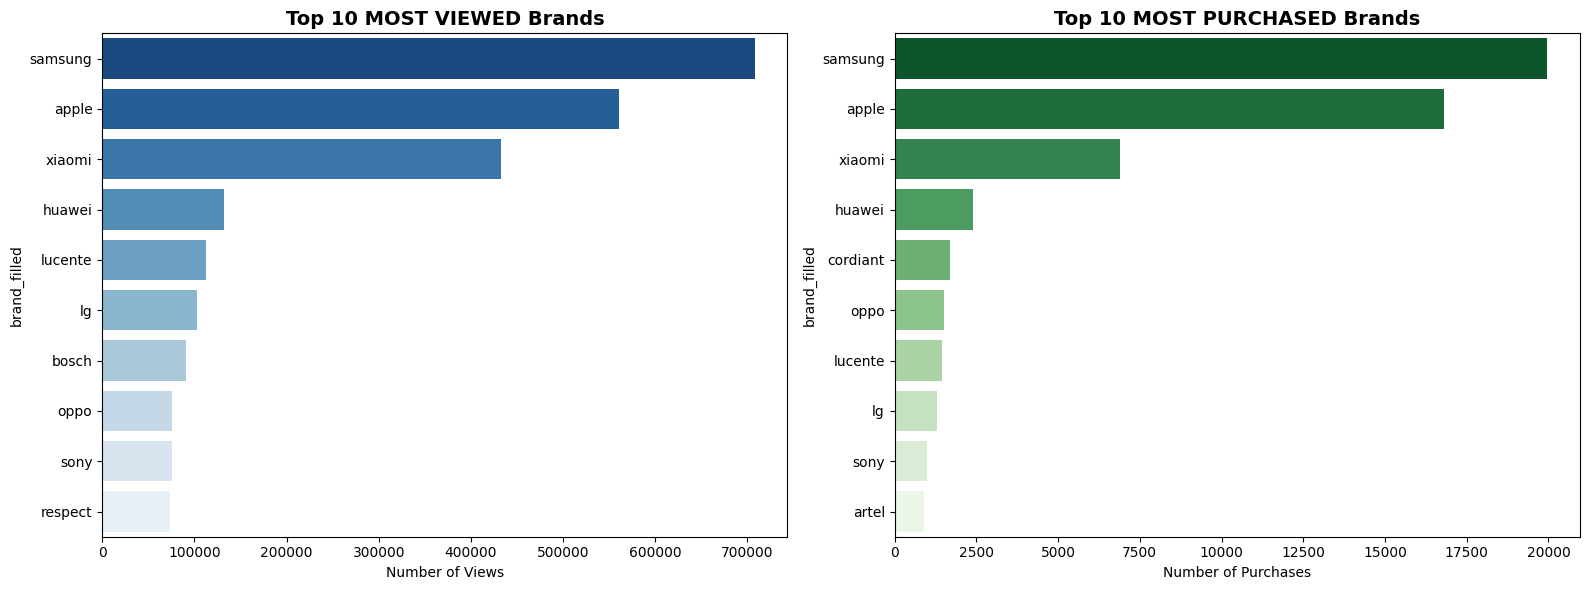

In [32]:
# 'unbranded' ko filter kar rahe hain actual brand insights ke liye
branded_df = final_df[final_df['brand_filled'] != 'unbranded']

# Top 10 Viewed Brands
top_viewed = branded_df[branded_df['event_type'] == 'view']['brand_filled'].value_counts().head(10)

# Top 10 Purchased Brands
top_purchased = branded_df[branded_df['event_type'] == 'purchase']['brand_filled'].value_counts().head(10)

# 2 subplots banayenge aamne-saamne compare karne ke liye
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left Graph: Views
sns.barplot(x=top_viewed.values, y=top_viewed.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 10 MOST VIEWED Brands', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Views')

# Right Graph: Purchases
sns.barplot(x=top_purchased.values, y=top_purchased.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 10 MOST PURCHASED Brands', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Purchases')

plt.tight_layout()
plt.show()

In [34]:
# Hum sirf view aur purchase ko compare karenge
price_data = final_df[final_df['event_type'].isin(['view', 'purchase'])]

In [36]:
price_data.head(10)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
4,2019-11-01 19:09:55+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
5,2019-11-01 19:11:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19
6,2019-11-01 19:12:49+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
7,2019-11-01 19:13:17+00:00,view,1005129,2053013555631882655,electronics.smartphone,apple,1329.44,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
8,2019-11-01 19:14:07+00:00,view,5100855,2053013553341792533,electronics.clocks,apple,548.02,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.clocks,apple,19
9,2019-11-01 19:14:58+00:00,view,1005073,2053013555631882655,electronics.smartphone,samsung,1133.09,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


In [ ]:
sns.boxplot(x='event_type', y='price', data=price_data, palette='Set2', showfliers=False)

plt.title('Price Distribution: Window Shopping vs. Actual Buying', fontsize=16, fontweight='bold')
plt.xlabel('User Action', fontsize=12)
plt.ylabel('Item Price ($)', fontsize=12)

plt.show()